{% def title Neural Networks With Matrices %}
{% def date 2023-07-30 %}
{% def tags machine-learning %}

{% template blog_post.html title date tags %}

There are a lot of online resources that show how neural networks works with scalar values[^1] (probably because it's easy to understand), but there are not enough of them talking about doing it using matrices. So, in this article I will build it up step by step on a single dense layer.

In [6]:
# {% out_only %}
import matplotlib.pyplot as plt
from IPython.display import SVG, display_svg
import io

def latex_text_to_svg(latex_expression):
    f = plt.figure(dpi=100)
    t = f.text(0, 0, f'${latex_expression}$', size=16, usetex=True)
    bb = t.get_window_extent()
    buffer = io.BytesIO()
    plt.gcf().set_size_inches(bb.width / 100, bb.height / 100)
    plt.axis('off')
    plt.savefig(buffer, format='svg', bbox_inches='tight')
    plt.close()
    display_svg(SVG(data=buffer.getvalue().decode()))
    buffer.close()

## Forward pass

First, let's go through forward pass using a single neuron.

- Each neuron in a network has a set of inputs which it receives from previous layer. We collect these in a vector and name that vector x. Each of the inputs can be represented as x<sup>i</sup>, where i is the corresponding input node.
- For each of these inputs, we have weights associated with it which tell how important that input is for the neuron. Let's put all these weights into a vector and call it w. We use the same notation as x for weights too.
- Let's call the neuron N.

Graphically, this is what a neuron will look like:

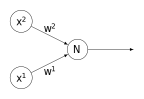

In [13]:
# {% out_only %}
from IPython.display import SVG, display

display(SVG('<svg xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink" version="1.1" width="300pt" height="200pt" viewBox="0 0 144.854 99.306"> <path transform="matrix(1,0,0,-1,77.999,49.653)" stroke-width=".3985" stroke-linecap="butt" stroke-miterlimit="10" stroke-linejoin="miter" fill="none" stroke="#000000" d="M10.32663 0C10.32663 5.70331 5.70331 10.32663 0 10.32663-5.70331 10.32663-10.32663 5.70331-10.32663 0-10.32663-5.70331-5.70331-10.32663 0-10.32663 5.70331-10.32663 10.32663-5.70331 10.32663 0ZM0 0"/> <text xml:space="preserve" transform="matrix(1 0 -0 1 0 99.306)" font-size="9.9626" font-family="CMMI10" font-style="italic"><tspan y="-46.249" x="73.454">N</tspan></text> <path transform="matrix(1,0,0,-1,77.999,49.653)" stroke-width=".3985" stroke-linecap="butt" stroke-miterlimit="10" stroke-linejoin="miter" fill="none" stroke="#000000" d="M-45.54874-28.3468C-45.54874-22.19159-50.53839-17.20193-56.69362-17.20193-62.84883-17.20193-67.83849-22.19159-67.83849-28.3468-67.83849-34.50203-62.84883-39.49168-56.69362-39.49168-50.53839-39.49168-45.54874-34.50203-45.54874-28.3468ZM-56.69362-28.3468"/> <text xml:space="preserve" transform="matrix(1 0 -0 1 .0000019073487 99.306)" font-size="9.9626" font-family="CMMI10" font-style="italic"><tspan y="-17.252" x="16.225">x</tspan></text> <text xml:space="preserve" transform="matrix(1 0 -0 1 .0000019073487 99.306)" font-size="6.9738" font-family="CMR7"><tspan y="-20.867" x="21.919">1</tspan></text> <path transform="matrix(1,0,0,-1,77.999,49.653)" stroke-width=".3985" stroke-linecap="butt" stroke-miterlimit="10" stroke-linejoin="miter" fill="none" stroke="#000000" d="M-45.54874 28.3468C-45.54874 34.50203-50.53839 39.49168-56.69362 39.49168-62.84883 39.49168-67.83849 34.50203-67.83849 28.3468-67.83849 22.19159-62.84883 17.20193-56.69362 17.20193-50.53839 17.20193-45.54874 22.19159-45.54874 28.3468ZM-56.69362 28.3468"/> <text xml:space="preserve" transform="matrix(1 0 -0 1 .0000019073487 99.306)" font-size="9.9626" font-family="CMMI10" font-style="italic"><tspan y="-73.945" x="16.225">x</tspan></text> <text xml:space="preserve" transform="matrix(1 0 -0 1 .0000019073487 99.306)" font-size="6.9738" font-family="CMR7"><tspan y="-77.56" x="21.919">2</tspan></text> <path transform="matrix(1,0,0,-1,77.999,49.653)" stroke-width=".3985" stroke-linecap="butt" stroke-miterlimit="10" stroke-linejoin="miter" fill="none" stroke="#000000" d="M-46.54784-23.274-12.62161-6.31068"/> <path transform="matrix(.89436,-.44717,-.44717,-.89436,65.37737,55.9637)" d="M3.58653 0C2.52383 .19925 .797 .797-.3985 1.49438V-1.49438C.797-.797 2.52383-.19925 3.58653 0"/> <text xml:space="preserve" transform="matrix(1 0 -0 1 0 99.306)" font-size="9.9626" font-family="CMMI10" font-style="italic"><tspan y="-24.033" x="44.084">w</tspan></text> <text xml:space="preserve" transform="matrix(1 0 -0 1 0 99.306)" font-size="6.9738" font-family="CMR7"><tspan y="-27.649" x="51.485">1</tspan></text> <path transform="matrix(1,0,0,-1,77.999,49.653)" stroke-width=".3985" stroke-linecap="butt" stroke-miterlimit="10" stroke-linejoin="miter" fill="none" stroke="#000000" d="M-46.54784 23.274-12.62161 6.31068"/> <path transform="matrix(.89436,.44717,.44717,-.89436,65.37737,43.3423)" d="M3.58653 0C2.52383 .19925 .797 .797-.3985 1.49438V-1.49438C.797-.797 2.52383-.19925 3.58653 0"/> <text xml:space="preserve" transform="matrix(1 0 -0 1 0 99.306)" font-size="9.9626" font-family="CMMI10" font-style="italic"><tspan y="-67.163" x="44.084">w</tspan></text> <text xml:space="preserve" transform="matrix(1 0 -0 1 0 99.306)" font-size="6.9738" font-family="CMR7"><tspan y="-70.778" x="51.485">2</tspan></text> <path transform="matrix(1,0,0,-1,77.999,49.653)" stroke-width=".3985" stroke-linecap="butt" stroke-miterlimit="10" stroke-linejoin="miter" fill="none" stroke="#000000" d="M10.5259 0H53.10709"/> <path transform="matrix(1,0,0,-1,131.1061,49.653)" d="M3.58653 0C2.52383 .19925 .797 .797-.3985 1.49438V-1.49438C.797-.797 2.52383-.19925 3.58653 0"/></svg>'))


There two things going on inside the neuron:

1. Weighted sum of the inputs
2. Passing the weighted sum into the activation function


## Backpropagation

Starting with backpro

[^1]: [Andrej Karpathy's Neural Networks: Zero to Hero (Video 1)](https://www.youtube.com/watch?v=VMj-3S1tku0&feature=youtu.be)